In [2]:
import scanpy as sc
import os
import scanpy as sc
import pandas as pd
import numpy as np
os.getcwd()

'/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type'

In [3]:
adata = sc.read_h5ad("../../3_small_integration/output_260420/small-concat-aggr-sparse-noCxG.h5ad")
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 495543 × 35428
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue'
    var: 'original_gene_names'
    layers: 'log1p_scran_samplewise', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

#### update plque type

In [4]:
adata.obs["Plaque_type"] = "Unknown"

In [4]:
datasets_to_change = [
    '1_JD',
    '2_ZDZJ',
    'AAA-MAX',
    'AAA-P',
    'AAA-PRO',
    'AIOD-3LIB',
    'AS-FA',
    'CFA-BWD',
    'CFA-PLA',
    'IAISR',
    'ISR-7-1',
    'POP-ISR-A',
    'POP-ISR2-B',
    'TAA-B1-5-3LIB',
    'TAA-A1-5-3LIB',
    'TAD1-Z3-3LIB',
    'TAD2-Z1-3LIB'
]
mask = adata.obs["dataset"].isin(datasets_to_change)
adata.obs.loc[mask, "Plaque_type"] = "Unstable"
adata_disease = adata[mask, :].copy()
adata_disease.obs["Plaque_type"].value_counts()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Plaque_type
Unstable    174298
Name: count, dtype: int64

In [5]:
datasets_to_change = [
    'AS-POP',
    'CBT',
    'IA-1-3LIB',
    'ISR-7-2',
    'ISR-8',
    'ISR-9',
    'SFA-8'
]
mask = adata.obs["dataset"].isin(datasets_to_change)
adata.obs.loc[mask, "Plaque_type"] = "Stable"
adata_disease = adata[mask, :].copy()
adata_disease.obs["Plaque_type"].value_counts()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Plaque_type
Stable    61315
Name: count, dtype: int64

In [6]:
adata.write("../../3_small_integration/output_260420/small-concat-aggr-sparse-noCxG-plaque_type.h5ad")

#### #prepare input

In [3]:
adata = sc.read_h5ad("./small-concat-aggr-sparse-noCxG-plaque_type.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
check = (
    adata.obs.groupby("sample")["Plaque_type"]
    .apply(lambda x: sorted(set(x.astype(str))))
)

print(check[check.apply(len) > 1].head(30))

Series([], Name: Plaque_type, dtype: object)


/tmp/ipykernel_3824119/1669186419.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("sample")["Plaque_type"]


In [5]:
sample_name = "1_JD"   # 换成报错里的任意一个
print(
    adata.obs.loc[adata.obs["sample"] == sample_name, "Plaque_type"]
    .value_counts(dropna=False)
)

Plaque_type
Unknown     15151
Stable          0
Unstable        0
Name: count, dtype: int64


In [7]:
import scanpy as sc
import pandas as pd
import numpy as np

# 1. 读取 h5ad
adata = sc.read_h5ad("./small-concat-aggr-sparse-noCxG-plaque_type.h5ad")
adata_new = adata[adata.obs["cell_type_level1"] != "unknown"].copy()

# 2. 列名
SAMPLE_COL = "sample"
CELLTYPE_COL = "cell_type_level1"

# 先清洗标签
adata_new.obs["Plaque_type_clean"] = (
    adata_new.obs["Plaque_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

LABEL_COL = "Plaque_type_clean"

# 3. 检查必要列
required_cols = [SAMPLE_COL, CELLTYPE_COL, LABEL_COL]
missing_cols = [c for c in required_cols if c not in adata_new.obs.columns]
if len(missing_cols) > 0:
    raise ValueError(f"adata_new.obs 缺少这些列: {missing_cols}")

obs = adata_new.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs = obs.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])

# 4. 只保留有明确标签的样本
train_obs = obs[obs[LABEL_COL].isin(["stable", "unstable"])].copy()

print("训练细胞数:", train_obs.shape[0])
print("标签分布:")
print(train_obs[LABEL_COL].value_counts())

# 5. 统计每个 sample 的各 cell type 细胞数
cell_count = pd.crosstab(train_obs[SAMPLE_COL], train_obs[CELLTYPE_COL])

# 转成比例
cell_prop = cell_count.div(cell_count.sum(axis=1), axis=0)
cell_prop.columns = [f"prop__{c}" for c in cell_prop.columns]

# 6. 提取 sample-level 标签
sample_label = (
    train_obs[[SAMPLE_COL, LABEL_COL]]
    .drop_duplicates()
    .groupby(SAMPLE_COL, observed=True)[LABEL_COL]
    .agg(lambda x: x.iloc[0] if len(set(x)) == 1 else "conflict")
)

conflict_samples = sample_label[sample_label == "conflict"].index.tolist()
if len(conflict_samples) > 0:
    print("仍然冲突的 sample:", conflict_samples[:20])
    raise ValueError("还有 sample 存在多个标签，请进一步检查。")

sample_label = sample_label.rename("label")

# 7. 对齐 X 和 y
common_samples = cell_prop.index.intersection(sample_label.index)
X_basic = cell_prop.loc[common_samples].copy()
y = sample_label.loc[common_samples].copy()

# 8. 编码标签
label_map = {"stable": 0, "unstable": 1}
y_num = y.map(label_map)

# 9. 看结果
print("X_basic shape:", X_basic.shape)
print("y shape:", y_num.shape)
print("\ny label counts:")
print(y.value_counts())

print("\nX_basic head:")
print(X_basic.head())

# 10. 保存
X_basic.to_csv("./output/X_basic_celltype_proportion.csv")
y.to_csv("./output/y_sample_label.csv", header=True)
y_num.to_csv("./output/y_sample_label_numeric.csv", header=True)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


训练细胞数: 220426
标签分布:
Plaque_type_clean
unstable    159125
stable       61301
Name: count, dtype: int64
X_basic shape: (23, 14)
y shape: (23,)

y label counts:
label
unstable    16
stable       7
Name: count, dtype: int64

X_basic head:
           prop__B cell  prop__Basophil  prop__Dendritic cell  \
sample                                                          
2_ZDZJ         0.404405             0.0              0.004468   
AAA_MAX        0.051504             0.0              0.035187   
AAA_P          0.058090             0.0              0.096629   
AAA_PRO        0.215568             0.0              0.084316   
AIOD_3LIB      0.092042             0.0              0.002524   

           prop__Endothelial cell  prop__Erythrocyte/Erythroid  \
sample                                                           
2_ZDZJ                   0.009062                          0.0   
AAA_MAX                  0.016033                          0.0   
AAA_P                    0.023933            

#### #train

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 如果没有安装 xgboost，先运行：
# pip install xgboost
from xgboost import XGBClassifier


# =========================
# 1. 读取输入数据
# =========================
X = pd.read_csv("./output/X_basic_celltype_proportion.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0)

# y 读出来通常是一列，把它转成一维向量
y = y.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\n标签分布:")
print(y.value_counts())


# =========================
# 2. 定义交叉验证
# =========================
# 5折分层交叉验证：每一折里 stable/unstable 比例尽量相近
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# =========================
# 3. Logistic Regression
# =========================
# 为什么加 StandardScaler？
# 因为 Logistic Regression 对特征尺度比较敏感，标准化后更稳定
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",   # 类别不平衡时更稳
        max_iter=1000,
        random_state=42
    ))
])

# cross_val_predict 会对每个样本做“折外预测”
# [:,1] 表示取预测为 unstable(1) 的概率
lr_pred_prob = cross_val_predict(
    lr_model, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

lr_pred_label = (lr_pred_prob >= 0.5).astype(int)

print("\n================ Logistic Regression ================")
print("AUROC:", roc_auc_score(y, lr_pred_prob))
print("AUPRC:", average_precision_score(y, lr_pred_prob))
print("Accuracy:", accuracy_score(y, lr_pred_label))
print("F1:", f1_score(y, lr_pred_label))
print("Confusion Matrix:")
print(confusion_matrix(y, lr_pred_label))
print("\nClassification Report:")
print(classification_report(y, lr_pred_label, digits=4))


# =========================
# 4. XGBoost
# =========================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_pred_prob = cross_val_predict(
    xgb_model, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

xgb_pred_label = (xgb_pred_prob >= 0.5).astype(int)

print("\n================ XGBoost ================")
print("AUROC:", roc_auc_score(y, xgb_pred_prob))
print("AUPRC:", average_precision_score(y, xgb_pred_prob))
print("Accuracy:", accuracy_score(y, xgb_pred_label))
print("F1:", f1_score(y, xgb_pred_label))
print("Confusion Matrix:")
print(confusion_matrix(y, xgb_pred_label))
print("\nClassification Report:")
print(classification_report(y, xgb_pred_label, digits=4))

X shape: (23, 14)
y shape: (23,)

标签分布:
label
1    16
0     7
Name: count, dtype: int64

================ Logistic Regression ================
AUROC: 0.7232142857142857
AUPRC: 0.8370560406333434
Accuracy: 0.6956521739130435
F1: 0.7878787878787878
Confusion Matrix:
[[ 3  4]
 [ 3 13]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5000    0.4286    0.4615         7
           1     0.7647    0.8125    0.7879        16

    accuracy                         0.6957        23
   macro avg     0.6324    0.6205    0.6247        23
weighted avg     0.6841    0.6957    0.6886        23


================ XGBoost ================
AUROC: 0.6875
AUPRC: 0.8363422168109668
Accuracy: 0.782608695652174
F1: 0.8648648648648649
Confusion Matrix:
[[ 2  5]
 [ 0 16]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.2857    0.4444         7
           1     0.7619    1.0000    0.8649        16

    ac

#### #add pesudo-bulk data

In [8]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

# =========================
# 1. 读取 h5ad
# =========================
adata = sc.read_h5ad("./small-concat-aggr-sparse-noCxG-plaque_type.h5ad")

# 去掉 unknown cell type
adata = adata[adata.obs["cell_type_level1"] != "unknown"].copy()


adata.var["original_feature_id"] = adata.var_names.astype(str)
adata.var_names = adata.var["original_gene_names"].astype(str)
adata.var_names_make_unique()

# =========================
# 2. 指定列名
# =========================
SAMPLE_COL = "sample"
CELLTYPE_COL = "cell_type_level1"

# 清洗标签
adata.obs["Plaque_type_clean"] = (
    adata.obs["Plaque_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)
LABEL_COL = "Plaque_type_clean"

# =========================
# 3. 只保留有明确 stable/unstable 标签的样本
# =========================
adata_train = adata[adata.obs[LABEL_COL].isin(["stable", "unstable"])].copy()

print("adata_train shape:", adata_train.shape)
print("label counts:")
print(adata_train.obs[LABEL_COL].value_counts())

# =========================
# 4. 定义 marker
# =========================
marker_dict = {
    "Macrophage": ["C1QA", "C1QB", "CD68", "AIF1", "LGALS3", "CD163"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "TAGLN", "CALD1", "NOTCH3", "PDGFRB"],
    "Endothelial cell": ["PECAM1", "VWF", "CLDN5", "CD34", "PLVAP", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "THY1"]
    # "Macrophage": ["C1QA", "LGALS3", "CD163", "IL1B", "FABP4", "MRC1"],
    # "Smooth muscle cell": ["ACTA2", "MYH11", "TAGLN", "NOTCH3", "FN1", "TNFRSF11B"],
    # "Endothelial cell": ["PECAM1", "VWF", "CLDN5", "ESM1", "SELE", "ICAM1", "KLF2"],
    # "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "THY1"],
    # "T cell": ["TRAC", "CD3D", "CD8A", "IL7R", "GZMK"]
}

# =========================
# 5. 检查 h5ad 里实际有哪些基因
# =========================
all_genes = set(adata_train.var_names)

filtered_marker_dict = {}
missing_marker_report = {}

for ct, genes in marker_dict.items():
    present = [g for g in genes if g in all_genes]
    missing = [g for g in genes if g not in all_genes]
    filtered_marker_dict[ct] = present
    missing_marker_report[ct] = missing

print("\n===== marker presence check =====")
for ct in marker_dict:
    print(f"{ct}:")
    print("  present:", filtered_marker_dict[ct])
    print("  missing:", missing_marker_report[ct])

filtered_marker_dict = {
    ct: genes for ct, genes in filtered_marker_dict.items() if len(genes) > 0
}

# =========================
# 6. 检查 cell type 名称是否真的存在
# =========================
all_celltypes = set(adata_train.obs[CELLTYPE_COL].astype(str).unique())
print("\n===== cell types in adata =====")
print(sorted(list(all_celltypes))[:50])

valid_celltypes = [ct for ct in filtered_marker_dict if ct in all_celltypes]
invalid_celltypes = [ct for ct in filtered_marker_dict if ct not in all_celltypes]

if len(invalid_celltypes) > 0:
    print("\n这些 marker_dict 里的 cell type 不在 adata.obs 里，请检查命名：")
    print(invalid_celltypes)

if len(valid_celltypes) == 0:
    raise ValueError("marker_dict 里的 cell type 一个都没匹配上，请先改 cell type 名称。")

filtered_marker_dict = {ct: filtered_marker_dict[ct] for ct in valid_celltypes}

# =========================
# 7. 平均表达函数
# =========================
def get_mean_expression(sub_adata, genes):
    if len(genes) == 0:
        return pd.Series(dtype=float)

    sub = sub_adata[:, genes]
    X = sub.X

    if sparse.issparse(X):
        mean_expr = np.asarray(X.mean(axis=0)).ravel()
    else:
        mean_expr = np.asarray(X.mean(axis=0)).ravel()

    return pd.Series(mean_expr, index=genes)

# =========================
# 8. 按 sample × cell_type 提取 pseudo-bulk marker 特征
# =========================
feature_rows = []
sample_ids = adata_train.obs[SAMPLE_COL].astype(str).unique().tolist()

for sample_id in sample_ids:
    sample_mask = adata_train.obs[SAMPLE_COL].astype(str) == str(sample_id)
    adata_sample = adata_train[sample_mask].copy()

    row_dict = {"sample": sample_id}

    for ct, genes in filtered_marker_dict.items():
        ct_mask = adata_sample.obs[CELLTYPE_COL].astype(str) == ct
        n_cells = int(ct_mask.sum())

        if n_cells == 0:
            for g in genes:
                row_dict[f"pb__{ct}__{g}"] = 0.0
            row_dict[f"pb_ncells__{ct}"] = 0
            continue

        adata_sub = adata_sample[ct_mask].copy()
        mean_expr = get_mean_expression(adata_sub, genes)

        for g in genes:
            row_dict[f"pb__{ct}__{g}"] = float(mean_expr[g])

        row_dict[f"pb_ncells__{ct}"] = n_cells

    feature_rows.append(row_dict)

X_pb = pd.DataFrame(feature_rows)
X_pb = X_pb.set_index("sample").sort_index()

print("\nX_pb shape:", X_pb.shape)
print(X_pb.head())

# =========================
# 9. 保存 pseudo-bulk 特征
# =========================
X_pb.to_csv("./output/X_pseudobulk_marker.csv")

# =========================
# 10. 和 X_basic 拼接
# =========================
X_basic = pd.read_csv("./output/X_basic_celltype_proportion.csv", index_col=0)

common_samples = X_basic.index.intersection(X_pb.index)
X_basic_aligned = X_basic.loc[common_samples].copy()
X_pb_aligned = X_pb.loc[common_samples].copy()

X_combined = pd.concat([X_basic_aligned, X_pb_aligned], axis=1)

print("\nX_combined shape:", X_combined.shape)
print(X_combined.head())

X_combined.to_csv("./output/X_combined_basic_plus_pseudobulk.csv")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


adata_train shape: (220426, 35428)
label counts:
Plaque_type_clean
unstable    159125
stable       61301
Name: count, dtype: int64

===== marker presence check =====
Macrophage:
  present: ['C1QA', 'C1QB', 'CD68', 'AIF1', 'LGALS3', 'CD163']
  missing: []
Smooth muscle cell:
  present: ['ACTA2', 'MYH11', 'TAGLN', 'CALD1', 'NOTCH3', 'PDGFRB']
  missing: []
Endothelial cell:
  present: ['PECAM1', 'VWF', 'CLDN5', 'CD34', 'PLVAP', 'EDN1']
  missing: []
Fibroblast:
  present: ['LUM', 'DCN', 'COL1A1', 'COL1A2', 'THY1']
  missing: []

===== cell types in adata =====
['B cell', 'Basophil', 'Dendritic cell', 'Endothelial cell', 'Erythrocyte/Erythroid', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Pericyte', 'Smooth muscle cell', 'T cell']

X_pb shape: (23, 27)
           pb__Macrophage__C1QA  pb__Macrophage__C1QB  pb__Macrophage__CD68  \
sample                                                                        
2_ZDZJ                12.967241    

#### #train again

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

# =========================
# 1. 读取新的组合特征
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0)

y = y.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\n标签分布:")
print(y.value_counts())

print("\n前10个特征名:")
print(X.columns[:10].tolist())

# =========================
# 2. 交叉验证设置
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 3. Logistic Regression
# =========================
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_pred_prob = cross_val_predict(
    lr_model, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

lr_pred_label = (lr_pred_prob >= 0.5).astype(int)

print("\n================ Logistic Regression (X_combined) ================")
print("AUROC:", roc_auc_score(y, lr_pred_prob))
print("AUPRC:", average_precision_score(y, lr_pred_prob))
print("Accuracy:", accuracy_score(y, lr_pred_label))
print("F1:", f1_score(y, lr_pred_label))
print("Confusion Matrix:")
print(confusion_matrix(y, lr_pred_label))
print("\nClassification Report:")
print(classification_report(y, lr_pred_label, digits=4))


# =========================
# 4. XGBoost
# =========================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_pred_prob = cross_val_predict(
    xgb_model, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

xgb_pred_label = (xgb_pred_prob >= 0.5).astype(int)

print("\n================ XGBoost (X_combined) ================")
print("AUROC:", roc_auc_score(y, xgb_pred_prob))
print("AUPRC:", average_precision_score(y, xgb_pred_prob))
print("Accuracy:", accuracy_score(y, xgb_pred_label))
print("F1:", f1_score(y, xgb_pred_label))
print("Confusion Matrix:")
print(confusion_matrix(y, xgb_pred_label))
print("\nClassification Report:")
print(classification_report(y, xgb_pred_label, digits=4))

X shape: (23, 41)
y shape: (23,)

标签分布:
label
1    16
0     7
Name: count, dtype: int64

前10个特征名:
['prop__B cell', 'prop__Basophil', 'prop__Dendritic cell', 'prop__Endothelial cell', 'prop__Erythrocyte/Erythroid', 'prop__Fibroblast', 'prop__Macrophage', 'prop__Mast cell', 'prop__Monocyte', 'prop__Natural killer cell']

================ Logistic Regression (X_combined) ================
AUROC: 0.9464285714285714
AUPRC: 0.9794270833333334
Accuracy: 0.8260869565217391
F1: 0.8823529411764706
Confusion Matrix:
[[ 4  3]
 [ 1 15]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8000    0.5714    0.6667         7
           1     0.8333    0.9375    0.8824        16

    accuracy                         0.8261        23
   macro avg     0.8167    0.7545    0.7745        23
weighted avg     0.8232    0.8261    0.8167        23


================ XGBoost (X_combined) ================
AUROC: 0.5892857142857143
AUPRC: 0.8179204658645448
Accuracy: 0.

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

# =========================
# 1. 读取新的组合特征
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0)

y = y.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\n标签分布:")
print(y.value_counts())

print("\n前10个特征名:")
print(X.columns[:10].tolist())

# =========================
# 2. 交叉验证设置
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 3. Logistic Regression
# =========================
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_pred_prob = cross_val_predict(
    lr_model, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

lr_pred_label = (lr_pred_prob >= 0.5).astype(int)

print("\n================ Logistic Regression (X_combined) ================")
print("AUROC:", roc_auc_score(y, lr_pred_prob))
print("AUPRC:", average_precision_score(y, lr_pred_prob))
print("Accuracy:", accuracy_score(y, lr_pred_label))
print("F1:", f1_score(y, lr_pred_label))
print("Confusion Matrix:")
print(confusion_matrix(y, lr_pred_label))
print("\nClassification Report:")
print(classification_report(y, lr_pred_label, digits=4))


# =========================
# 4. XGBoost
# =========================
pos = (y == 1).sum()
neg = (y == 0).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)

xgb_pred_prob = cross_val_predict(
    xgb_model, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

xgb_pred_label = (xgb_pred_prob >= 0.5).astype(int)

print("\n================ XGBoost (X_combined) ================")
print("AUROC:", roc_auc_score(y, xgb_pred_prob))
print("AUPRC:", average_precision_score(y, xgb_pred_prob))
print("Accuracy:", accuracy_score(y, xgb_pred_label))
print("F1:", f1_score(y, xgb_pred_label))
print("Confusion Matrix:")
print(confusion_matrix(y, xgb_pred_label))
print("\nClassification Report:")
print(classification_report(y, xgb_pred_label, digits=4))

X shape: (23, 41)
y shape: (23,)

标签分布:
label
1    16
0     7
Name: count, dtype: int64

前10个特征名:
['prop__B cell', 'prop__Basophil', 'prop__Dendritic cell', 'prop__Endothelial cell', 'prop__Erythrocyte/Erythroid', 'prop__Fibroblast', 'prop__Macrophage', 'prop__Mast cell', 'prop__Monocyte', 'prop__Natural killer cell']

================ Logistic Regression (X_combined) ================
AUROC: 0.9464285714285714
AUPRC: 0.9794270833333334
Accuracy: 0.8260869565217391
F1: 0.8823529411764706
Confusion Matrix:
[[ 4  3]
 [ 1 15]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8000    0.5714    0.6667         7
           1     0.8333    0.9375    0.8824        16

    accuracy                         0.8261        23
   macro avg     0.8167    0.7545    0.7745        23
weighted avg     0.8232    0.8261    0.8167        23


================ XGBoost (X_combined) ================
AUROC: 0.39285714285714285
AUPRC: 0.6728597483513816
Accuracy: 0

In [ ]:
###逻辑回归每折的准确性
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, confusion_matrix

X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    fold_results.append({
        "fold": fold_idx,
        "n_test": len(test_idx),
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    })

fold_df = pd.DataFrame(fold_results)
print(fold_df[["fold", "n_test", "AUROC", "AUPRC", "Accuracy", "F1"]])

print("\nMean:")
print(fold_df[["AUROC", "AUPRC", "Accuracy", "F1"]].mean())

print("\nStd:")
print(fold_df[["AUROC", "AUPRC", "Accuracy", "F1"]].std())

   fold  n_test     AUROC     AUPRC  Accuracy        F1
0     1       5  1.000000  1.000000      0.80  0.888889
1     2       5  1.000000  1.000000      1.00  1.000000
2     3       5  0.833333  0.916667      0.60  0.666667
3     4       4  1.000000  1.000000      1.00  1.000000
4     5       4  0.333333  0.805556      0.75  0.857143

Mean:
AUROC       0.833333
AUPRC       0.944444
Accuracy    0.830000
F1          0.882540
dtype: float64

Std:
AUROC       0.288675
AUPRC       0.085617
Accuracy    0.171756
F1          0.136821
dtype: float64


#### #Data enhancement and train

In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# 1. 读取数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\n标签分布:")
print(y.value_counts())

# =========================
# 2. 区分不同类型特征
# =========================
prop_cols = [c for c in X.columns if c.startswith("prop__")]
pb_cols = [c for c in X.columns if c.startswith("pb__") and not c.startswith("pb_ncells__")]
count_cols = [c for c in X.columns if c.startswith("pb_ncells__")]

print("\nprop features:", len(prop_cols))
print("pb features:", len(pb_cols))
print("count features:", len(count_cols))

rng = np.random.default_rng(42)

# =========================
# 3. 定义增强函数
# =========================
def augment_training_data(X_train, y_train, n_aug_per_sample=5,
                          prop_noise=0.02, pb_noise_scale=0.05, count_noise_scale=0.05):
    """
    只对训练集做增强
    每个样本生成 n_aug_per_sample 个近邻样本
    """
    aug_rows = []
    aug_labels = []

    for idx in X_train.index:
        row = X_train.loc[idx].copy()
        label = y_train.loc[idx]

        for _ in range(n_aug_per_sample):
            new_row = row.copy()

            # 1) 比例特征：加小噪声，再重新归一化
            if len(prop_cols) > 0:
                vals = new_row[prop_cols].values.astype(float)
                noise = rng.normal(0, prop_noise, size=len(prop_cols))
                vals = vals + noise
                vals = np.clip(vals, 0, None)

                s = vals.sum()
                if s > 0:
                    vals = vals / s

                new_row[prop_cols] = vals

            # 2) pseudo-bulk marker：按相对幅度加小噪声
            if len(pb_cols) > 0:
                vals = new_row[pb_cols].values.astype(float)
                noise = rng.normal(0, pb_noise_scale, size=len(pb_cols))
                vals = vals + noise * (np.abs(vals) + 1e-3)
                vals = np.clip(vals, 0, None)
                new_row[pb_cols] = vals

            # 3) 细胞数特征：轻微扰动后取整
            if len(count_cols) > 0:
                vals = new_row[count_cols].values.astype(float)
                noise = rng.normal(0, count_noise_scale, size=len(count_cols))
                vals = vals + noise * np.maximum(vals, 1)
                vals = np.clip(np.round(vals), 0, None)
                new_row[count_cols] = vals

            aug_rows.append(new_row)
            aug_labels.append(label)

    X_aug = pd.DataFrame(aug_rows)
    X_aug.index = [f"aug_{i}" for i in range(len(X_aug))]
    y_aug = pd.Series(aug_labels, index=X_aug.index, name=y_train.name)

    return X_aug, y_aug

# =========================
# 4. 手动5折CV：每折只增强训练集
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_test_probs = pd.Series(index=X.index, dtype=float)
all_test_preds = pd.Series(index=X.index, dtype=int)

fold_results = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

    # ===== 只增强训练集 =====
    X_aug, y_aug = augment_training_data(
        X_train, y_train,
        n_aug_per_sample=5,   # 每个真实训练样本生成5个增强样本
        prop_noise=0.02,
        pb_noise_scale=0.05,
        count_noise_scale=0.05
    )

    # 拼接：真实训练样本 + 增强样本
    X_train_full = pd.concat([X_train, X_aug], axis=0)
    y_train_full = pd.concat([y_train, y_aug], axis=0)

    print(f"\nFold {fold_idx}:")
    print("  原始训练样本数:", X_train.shape[0])
    print("  增强训练样本数:", X_aug.shape[0])
    print("  最终训练样本数:", X_train_full.shape[0])
    print("  测试样本数:", X_test.shape[0])

    # 模型
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(X_train_full, y_train_full)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.6).astype(int)

    # 保存每个测试样本的折外预测
    all_test_probs.iloc[test_idx] = y_prob
    all_test_preds.iloc[test_idx] = y_pred

    fold_results.append({
        "fold": fold_idx,
        "n_test": len(test_idx),
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    })

# =========================
# 5. 输出每折结果
# =========================
fold_df = pd.DataFrame(fold_results)

print("\n================ 每折结果（训练集增强） ================")
print(fold_df[["fold", "n_test", "AUROC", "AUPRC", "Accuracy", "F1"]])

print("\nMean:")
print(fold_df[["AUROC", "AUPRC", "Accuracy", "F1"]].mean())

print("\nStd:")
print(fold_df[["AUROC", "AUPRC", "Accuracy", "F1"]].std())

# =========================
# 6. 输出总体折外预测结果
# =========================
print("\n================ 总体结果（训练集增强） ================")
print("AUROC:", roc_auc_score(y, all_test_probs))
print("AUPRC:", average_precision_score(y, all_test_probs))
print("Accuracy:", accuracy_score(y, all_test_preds))
print("F1:", f1_score(y, all_test_preds))
print("Confusion Matrix:")
print(confusion_matrix(y, all_test_preds))
print("\nClassification Report:")
print(classification_report(y, all_test_preds, digits=4))

X shape: (23, 41)
y shape: (23,)

标签分布:
label
1    16
0     7
Name: count, dtype: int64

prop features: 14
pb features: 23
count features: 4

Fold 1:
  原始训练样本数: 18
  增强训练样本数: 90
  最终训练样本数: 108
  测试样本数: 5

Fold 2:
  原始训练样本数: 18
  增强训练样本数: 90
  最终训练样本数: 108
  测试样本数: 5

Fold 3:
  原始训练样本数: 18
  增强训练样本数: 90
  最终训练样本数: 108
  测试样本数: 5

Fold 4:
  原始训练样本数: 19
  增强训练样本数: 95
  最终训练样本数: 114
  测试样本数: 4

Fold 5:
  原始训练样本数: 19
  增强训练样本数: 95
  最终训练样本数: 114
  测试样本数: 4

================ 每折结果（训练集增强） ================
   fold  n_test     AUROC     AUPRC  Accuracy        F1
0     1       5  1.000000  1.000000      0.80  0.888889
1     2       5  1.000000  1.000000      1.00  1.000000
2     3       5  1.000000  1.000000      1.00  1.000000
3     4       4  1.000000  1.000000      1.00  1.000000
4     5       4  0.333333  0.805556      0.75  0.857143

Mean:
AUROC       0.866667
AUPRC       0.961111
Accuracy    0.910000
F1          0.949206
dtype: float64

Std:
AUROC       0.298142
AUPRC       0.086958
Accurac

#### with other unknown

##### prepare input

In [8]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

# =========================
# 0. 参数设置
# =========================
H5AD_PATH = "../../3_small_integration/output_260420/small-concat-aggr-sparse-noCxG-plaque_type.h5ad"

SAMPLE_COL = "sample"
CELLTYPE_COL = "cell_type_level1"
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

TRAIN_X_BASIC_PATH = "./output/X_basic_celltype_proportion.csv"
TRAIN_X_PB_PATH = "./output/X_pseudobulk_marker.csv"
TRAIN_X_COMBINED_PATH = "./output/X_combined_basic_plus_pseudobulk.csv"

OUT_X_BASIC_UNKNOWN = "./output/X_basic_unknown_celltype_proportion.csv"
OUT_X_PB_UNKNOWN = "./output/X_pseudobulk_marker_unknown.csv"
OUT_X_UNKNOWN_COMBINED = "./output/X_unknown_combined_basic_plus_pseudobulk.csv"

# 必须和训练时一致
marker_dict = {
    "Macrophage": ["C1QA", "C1QB", "CD68", "AIF1", "LGALS3", "CD163"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "TAGLN", "CALD1", "NOTCH3", "PDGFRB"],
    "Endothelial cell": ["PECAM1", "VWF", "CLDN5", "CD34", "PLVAP", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "THY1"]
}

# =========================
# 1. 读取 h5ad
# =========================
print("Reading h5ad...")
adata = sc.read_h5ad(H5AD_PATH)

# 去掉 unknown cell type（这里是细胞类型 unknown，不是样本标签 unknown）
adata = adata[adata.obs[CELLTYPE_COL] != "unknown"].copy()

# 用真实基因名替换 var_names
adata.var["original_feature_id"] = adata.var_names.astype(str)
adata.var_names = adata.var["original_gene_names"].astype(str)
adata.var_names_make_unique()

# 清洗样本标签
adata.obs[LABEL_COL] = (
    adata.obs[LABEL_RAW_COL]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("adata shape after filtering unknown cell type:", adata.shape)
print("sample label distribution:")
print(adata.obs[LABEL_COL].value_counts(dropna=False))

# =========================
# 2. 检查必要列
# =========================
required_obs_cols = [SAMPLE_COL, CELLTYPE_COL, LABEL_COL]
missing_cols = [c for c in required_obs_cols if c not in adata.obs.columns]
if len(missing_cols) > 0:
    raise ValueError(f"adata.obs 缺少这些列: {missing_cols}")

# =========================
# 3. 只保留 unknown 样本
# =========================
adata_unknown = adata[adata.obs[LABEL_COL].isin(["unknown"])].copy()

print("\nadata_unknown shape:", adata_unknown.shape)
print("unknown label counts:")
print(adata_unknown.obs[LABEL_COL].value_counts())

if adata_unknown.n_obs == 0:
    raise ValueError("没有找到标签为 unknown 的样本。")

# =========================
# 4. 生成 X_basic_unknown
# =========================
print("\nBuilding X_basic_unknown...")

obs_unknown = adata_unknown.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs_unknown = obs_unknown.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])

cell_count = pd.crosstab(obs_unknown[SAMPLE_COL], obs_unknown[CELLTYPE_COL])
cell_prop = cell_count.div(cell_count.sum(axis=1), axis=0)
cell_prop.columns = [f"prop__{c}" for c in cell_prop.columns]

X_basic_unknown = cell_prop.copy()

print("Raw X_basic_unknown shape:", X_basic_unknown.shape)
print(X_basic_unknown.head())

# 和训练时 X_basic 列对齐
X_basic_train = pd.read_csv(TRAIN_X_BASIC_PATH, index_col=0)
X_basic_unknown = X_basic_unknown.reindex(columns=X_basic_train.columns, fill_value=0)

print("\nAligned X_basic_unknown shape:", X_basic_unknown.shape)
print(X_basic_unknown.head())

X_basic_unknown.to_csv(OUT_X_BASIC_UNKNOWN)
print(f"Saved: {OUT_X_BASIC_UNKNOWN}")

# =========================
# 5. 生成 X_pb_unknown
# =========================
print("\nBuilding X_pb_unknown...")

all_genes = set(adata_unknown.var_names)

filtered_marker_dict = {}
missing_marker_report = {}

for ct, genes in marker_dict.items():
    present = [g for g in genes if g in all_genes]
    missing = [g for g in genes if g not in all_genes]
    filtered_marker_dict[ct] = present
    missing_marker_report[ct] = missing

print("\n===== marker presence check =====")
for ct in marker_dict:
    print(f"{ct}:")
    print("  present:", filtered_marker_dict[ct])
    print("  missing:", missing_marker_report[ct])

filtered_marker_dict = {
    ct: genes for ct, genes in filtered_marker_dict.items() if len(genes) > 0
}

all_celltypes = set(adata_unknown.obs[CELLTYPE_COL].astype(str).unique())
print("\n===== cell types in adata_unknown =====")
print(sorted(list(all_celltypes))[:50])

valid_celltypes = [ct for ct in filtered_marker_dict if ct in all_celltypes]
invalid_celltypes = [ct for ct in filtered_marker_dict if ct not in all_celltypes]

if len(invalid_celltypes) > 0:
    print("\nThese marker_dict cell types are not present in adata_unknown.obs:")
    print(invalid_celltypes)

filtered_marker_dict = {ct: filtered_marker_dict[ct] for ct in valid_celltypes}

if len(filtered_marker_dict) == 0:
    raise ValueError("没有任何有效的 cell type + marker 组合可以用于 unknown 样本。")

def get_mean_expression(sub_adata, genes):
    if len(genes) == 0:
        return pd.Series(dtype=float)

    sub = sub_adata[:, genes]
    X = sub.X

    if sparse.issparse(X):
        mean_expr = np.asarray(X.mean(axis=0)).ravel()
    else:
        mean_expr = np.asarray(X.mean(axis=0)).ravel()

    return pd.Series(mean_expr, index=genes)

feature_rows = []
sample_ids = adata_unknown.obs[SAMPLE_COL].astype(str).unique().tolist()

for sample_id in sample_ids:
    sample_mask = adata_unknown.obs[SAMPLE_COL].astype(str) == str(sample_id)
    adata_sample = adata_unknown[sample_mask].copy()

    row_dict = {"sample": sample_id}

    for ct, genes in filtered_marker_dict.items():
        ct_mask = adata_sample.obs[CELLTYPE_COL].astype(str) == ct
        n_cells = int(ct_mask.sum())

        if n_cells == 0:
            for g in genes:
                row_dict[f"pb__{ct}__{g}"] = 0.0
            row_dict[f"pb_ncells__{ct}"] = 0
            continue

        adata_sub = adata_sample[ct_mask].copy()
        mean_expr = get_mean_expression(adata_sub, genes)

        for g in genes:
            row_dict[f"pb__{ct}__{g}"] = float(mean_expr[g])

        row_dict[f"pb_ncells__{ct}"] = n_cells

    feature_rows.append(row_dict)

X_pb_unknown = pd.DataFrame(feature_rows)
X_pb_unknown = X_pb_unknown.set_index("sample").sort_index()

print("\nRaw X_pb_unknown shape:", X_pb_unknown.shape)
print(X_pb_unknown.head())

# 和训练时 pseudo-bulk 特征列对齐
X_pb_train = pd.read_csv(TRAIN_X_PB_PATH, index_col=0)
X_pb_unknown = X_pb_unknown.reindex(columns=X_pb_train.columns, fill_value=0)

print("\nAligned X_pb_unknown shape:", X_pb_unknown.shape)
print(X_pb_unknown.head())

X_pb_unknown.to_csv(OUT_X_PB_UNKNOWN)
print(f"Saved: {OUT_X_PB_UNKNOWN}")

# =========================
# 6. 拼接成 X_unknown_combined
# =========================
print("\nBuilding X_unknown_combined...")

common_samples = X_basic_unknown.index.intersection(X_pb_unknown.index)

X_unknown_combined = pd.concat(
    [X_basic_unknown.loc[common_samples], X_pb_unknown.loc[common_samples]],
    axis=1
)

# 再和训练时最终特征列完全对齐
X_train_combined = pd.read_csv(TRAIN_X_COMBINED_PATH, index_col=0)
X_unknown_combined = X_unknown_combined.reindex(columns=X_train_combined.columns, fill_value=0)

print("Final X_unknown_combined shape:", X_unknown_combined.shape)
print(X_unknown_combined.head())

X_unknown_combined.to_csv(OUT_X_UNKNOWN_COMBINED)
print(f"Saved: {OUT_X_UNKNOWN_COMBINED}")

print("\nDone.")

Reading h5ad...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


adata shape after filtering unknown cell type: (495507, 35428)
sample label distribution:
Plaque_type_clean
unknown     259930
unsatble    174276
satble       61301
Name: count, dtype: int64


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



adata_unknown shape: (259930, 35428)
unknown label counts:
Plaque_type_clean
unknown    259930
Name: count, dtype: int64

Building X_basic_unknown...
Raw X_basic_unknown shape: (25, 14)
            prop__B cell  prop__Basophil  prop__Dendritic cell  \
sample                                                           
3_AAA           0.048297             0.0              0.001481   
AAA_1_3LIB      0.080859             0.0              0.014458   
AAA_2_3LIB      0.111655             0.0              0.027496   
AAA_3_3LIB      0.078929             0.0              0.168590   
AAA_4_3LIB      0.076504             0.0              0.001640   

            prop__Endothelial cell  prop__Erythrocyte/Erythroid  \
sample                                                            
3_AAA                     0.031780                          0.0   
AAA_1_3LIB                0.009090                          0.0   
AAA_2_3LIB                0.016476                          0.0   
AAA_3_3LIB     

##### train

In [ ]:
# 这个是把有标签的数据全部拿来训练 没有标签的数据拿来预测-----没办法看预测准确性
# import pandas as pd
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# # 训练集
# X_train = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
# y_train = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# # 训练最终模型
# final_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("clf", LogisticRegression(
#         penalty="l2",
#         C=1.0,
#         class_weight="balanced",
#         max_iter=1000,
#         random_state=42
#     ))
# ])

# final_model.fit(X_train, y_train)

# # unknown 特征
# X_unknown = pd.read_csv("./output/X_unknown_combined_basic_plus_pseudobulk.csv", index_col=0)
# X_unknown = X_unknown.reindex(columns=X_train.columns, fill_value=0)

# # 预测 unstable 概率
# prob_unstable = final_model.predict_proba(X_unknown)[:, 1]

# result = pd.DataFrame({
#     "sample_id": X_unknown.index,
#     "prob_unstable": prob_unstable
# })

# # 按 0.6 阈值
# result["pred_label_0.6"] = (result["prob_unstable"] >= 0.6).astype(int)
# result["pred_label_0.6"] = result["pred_label_0.6"].map({
#     1: "unstable",
#     0: "non-unstable"
# })

# # 三档解释
# def assign_3class(p):
#     if p >= 0.8:
#         return "high-confidence unstable"
#     elif p >= 0.6:
#         return "unstable-like"
#     else:
#         return "non-unstable"

# result["pred_3class"] = result["prob_unstable"].apply(assign_3class)

# print(result.sort_values("prob_unstable", ascending=False))
# result.to_csv("./output/unknown_prediction_final_lr.csv", index=False)

             sample_id  prob_unstable pred_label_0.6               pred_3class
7                AAA_9       0.997424       unstable  high-confidence unstable
21              TAA_Z3       0.996855       unstable  high-confidence unstable
20              TAA_Z1       0.994187       unstable  high-confidence unstable
22        TAD2_Z2_3LIB       0.993712       unstable  high-confidence unstable
24      TAD_AD1_2_3LIB       0.993119       unstable  high-confidence unstable
2           AAA_1_3LIB       0.987794       unstable  high-confidence unstable
3           AAA_2_3LIB       0.985235       unstable  high-confidence unstable
23        TAD2_Z3_3LIB       0.973533       unstable  high-confidence unstable
5           AAA_4_3LIB       0.962783       unstable  high-confidence unstable
6                AAA_8       0.844989       unstable  high-confidence unstable
1                3_AAA       0.832300       unstable  high-confidence unstable
0                 1_JD       0.789074       unstable

#### 折线图-5次求平均

In [9]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 5

# unstable 判定阈值
threshold = 0.6

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output/lr_train_size_cv_summary.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output/lr_train_size_cv_all_fold_predictions.csv",
    index=False
)

print("\nSaved:")
print("./output/lr_train_size_cv_summary.csv")
print("./output/lr_train_size_cv_all_fold_predictions.csv")

X shape: (23, 41)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.8095, F1 = 0.7143
Confusion matrix:
[[1 2]
 [2 5]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.8095, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 1.0000, AUC = 1.0000, F1 = 1.0000
Confusion matrix:
[[3 0]
 [0 7]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.8095, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Training size = 65%, Holdout size = 35%

Fold 1
n_train = 14, n_test = 9
Accuracy = 0.7778, AUC = 0.8889, F1 = 0.8333
Confusion matrix:
[[2 1]
 [1 5]]

Fold 2
n_train = 14, n_test = 9
Accuracy = 0.7778, AUC = 0.7778, F1 = 0.8571
Confusion matrix:
[[1 2]
 [0 6]]

Fold 3
n_train = 14, n_test = 9
Accuracy = 0.7778, AU

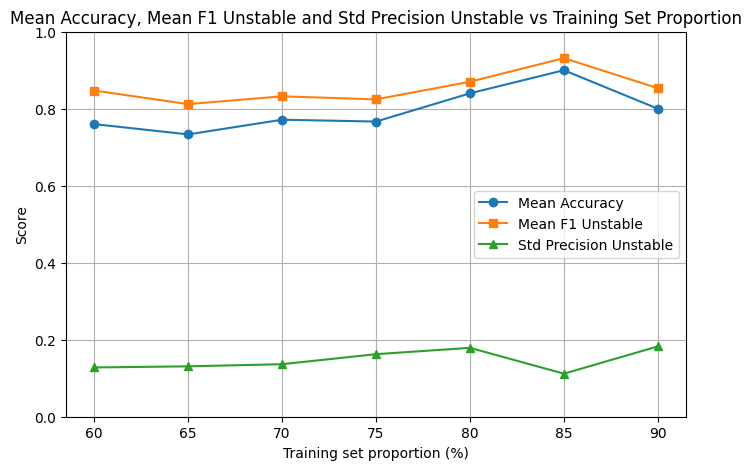

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output/lr_train_size_cv_summary.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

#### 折线图---10次求平均

In [6]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 10

# unstable 判定阈值
threshold = 0.5

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output/lr_train_size_cv_summary_10.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output/lr_train_size_cv_all_fold_predictions_10.csv",
    index=False
)

print("\nSaved:")
print("./output/lr_train_size_cv_summary_10.csv")
print("./output/lr_train_size_cv_all_fold_predictions_10.csv")

X shape: (23, 41)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.8095, F1 = 0.7143
Confusion matrix:
[[1 2]
 [2 5]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.8095, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 1.0000, AUC = 1.0000, F1 = 1.0000
Confusion matrix:
[[3 0]
 [0 7]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.8095, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 6
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.7143, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 7
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.8095, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 8
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.5714, F1 = 0.7500
Confusion matr

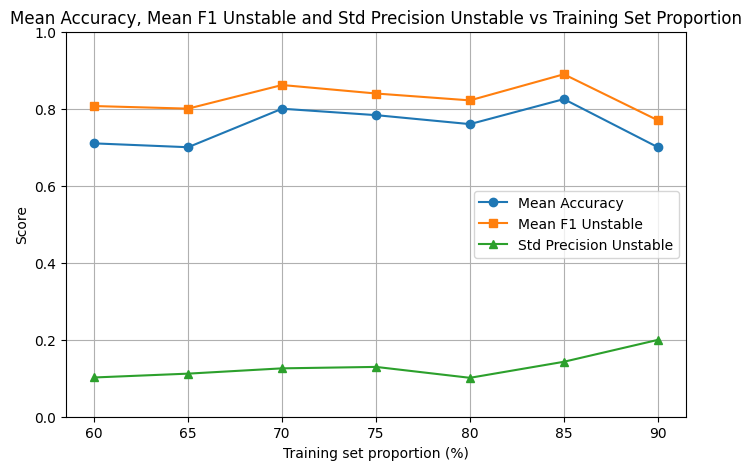

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output/lr_train_size_cv_summary_10.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

#### 折线图----100次求平均

In [8]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 100

# unstable 判定阈值
threshold = 0.5

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output/lr_train_size_cv_summary_100.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output/lr_train_size_cv_all_fold_predictions_100.csv",
    index=False
)

print("\nSaved:")
print("./output/lr_train_size_cv_summary_100.csv")
print("./output/lr_train_size_cv_all_fold_predictions_100.csv")

X shape: (23, 41)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.8095, F1 = 0.7143
Confusion matrix:
[[1 2]
 [2 5]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.8095, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 1.0000, AUC = 1.0000, F1 = 1.0000
Confusion matrix:
[[3 0]
 [0 7]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.8095, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 6
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.7143, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 7
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.8095, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 8
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.5714, F1 = 0.7500
Confusion matr

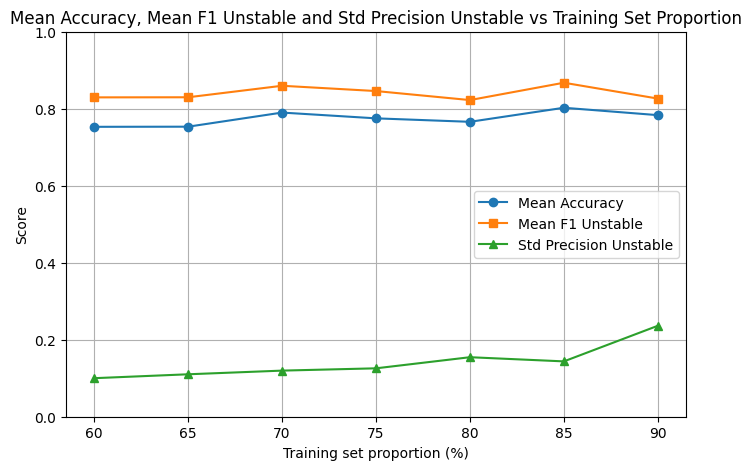

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output/lr_train_size_cv_summary_100.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

In [ ]:
####标签集85%训练15%预测
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

# =========================
# 2. 80% 训练，20% 留出验证
# =========================
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=None,
    stratify=y
)

# =========================
# 3. 训练模型
# =========================
model_85 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=None
    ))
])

model_85.fit(X_train, y_train)

# =========================
# 4. 在 20% holdout 上验证
# =========================
prob_holdout = model_85.predict_proba(X_holdout)[:, 1]

holdout_result = pd.DataFrame({
    "sample_id": X_holdout.index,
    "true_label_numeric": y_holdout.values,
    "prob_unstable": prob_holdout
})

holdout_result["pred_label_0.6_numeric"] = (
    holdout_result["prob_unstable"] >= 0.6
).astype(int)

holdout_result["true_label"] = holdout_result["true_label_numeric"].map({
    1: "unstable",
    0: "non-unstable"
})

holdout_result["pred_label_0.6"] = holdout_result["pred_label_0.6_numeric"].map({
    1: "unstable",
    0: "non-unstable"
})

def assign_3class(p):
    if p >= 0.8:
        return "high-confidence unstable"
    elif p >= 0.6:
        return "unstable-like"
    else:
        return "non-unstable"

holdout_result["pred_3class"] = holdout_result["prob_unstable"].apply(assign_3class)

print("===== Holdout validation result =====")
print(holdout_result.sort_values("prob_unstable", ascending=False))

print("\n===== Classification report, threshold = 0.6 =====")
print(classification_report(
    holdout_result["true_label_numeric"],
    holdout_result["pred_label_0.6_numeric"],
    target_names=["non-unstable", "unstable"]
))

print("\n===== Confusion matrix =====")
print(confusion_matrix(
    holdout_result["true_label_numeric"],
    holdout_result["pred_label_0.6_numeric"]
))

if len(set(y_holdout)) == 2:
    print("\n===== ROC AUC =====")
    print(roc_auc_score(y_holdout, prob_holdout))

holdout_result.to_csv(
    "./output/holdout_20_prediction_lr.csv",
    index=False
)

# =========================
# 5. 读取真正 unknown
# =========================
X_unknown = pd.read_csv(
    "./output/X_unknown_combined_basic_plus_pseudobulk.csv",
    index_col=0
)

X_unknown = X_unknown.reindex(columns=X.columns, fill_value=0)

# =========================
# 6. 把 holdout 20% 和 unknown 放在一起预测
# =========================
X_holdout_for_pred = X_holdout.reindex(columns=X.columns, fill_value=0)

X_predict_all = pd.concat([
    X_holdout_for_pred,
    X_unknown
], axis=0)

sample_type = (
    ["holdout_labeled_20pct"] * X_holdout_for_pred.shape[0]
    + ["unknown"] * X_unknown.shape[0]
)

prob_all = model_85.predict_proba(X_predict_all)[:, 1]

all_result = pd.DataFrame({
    "sample_id": X_predict_all.index,
    "sample_type": sample_type,
    "prob_unstable": prob_all
})

# 对 holdout 样本补上真实标签，unknown 没有真实标签
true_label_map = y_holdout.to_dict()
all_result["true_label_numeric"] = all_result["sample_id"].map(true_label_map)

all_result["pred_label_0.6"] = (
    all_result["prob_unstable"] >= 0.5
).astype(int).map({
    1: "unstable",
    0: "non-unstable"
})

all_result["pred_3class"] = all_result["prob_unstable"].apply(assign_3class)

print("\n===== Holdout 20% + unknown prediction =====")
print(all_result.sort_values("prob_unstable", ascending=False))

all_result.to_csv(
    "./output/holdout20_plus_unknown_prediction_lr.csv",
    index=False
)

===== Holdout validation result =====
  sample_id  true_label_numeric  prob_unstable  pred_label_0.6_numeric  \
2   AAA_PRO                   1       0.981925                       1   
3     AS_FA                   1       0.943096                       1   
1   CFA_PLA                   1       0.304096                       0   
0     SFA_8                   0       0.000134                       0   

     true_label pred_label_0.6               pred_3class  
2      unstable       unstable  high-confidence unstable  
3      unstable       unstable  high-confidence unstable  
1      unstable   non-unstable              non-unstable  
0  non-unstable   non-unstable              non-unstable  

===== Classification report, threshold = 0.6 =====
              precision    recall  f1-score   support

non-unstable       0.50      1.00      0.67         1
    unstable       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75   

### test